(49999, 128, 128, 3) train samples
(10001, 128, 128, 3) test samples
Found 49999 validated image filenames.
Found 10001 validated image filenames.


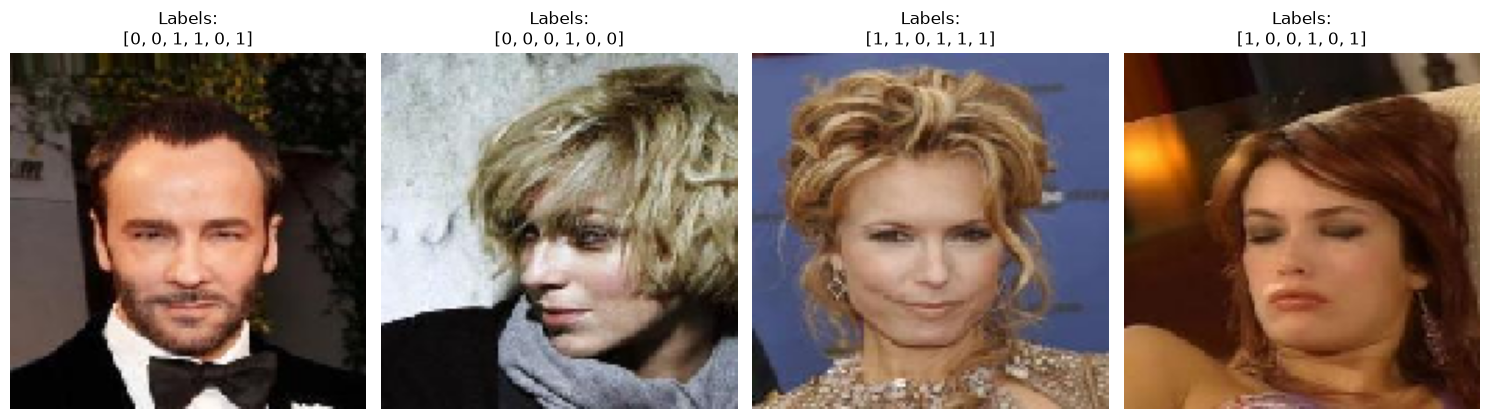

C:\Users\Shiraz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 152s 193ms/step - accuracy: 0.2414 - loss: 0.4530 - val_accuracy: 0.3311 - val_loss: 0.3375
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 185ms/step - accuracy: 0.3067 - loss: 0.3532 - val_accuracy: 0.3350 - val_loss: 0.3120
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 177ms/step - accuracy: 0.3130 - loss: 0.3286 - val_accuracy: 0.3285 - val_loss: 0.3026
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 175ms/step - accuracy: 0.3175 - loss: 0.3119 - val_accuracy: 0.3250 - val_loss: 0.2968
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 174ms/step - accuracy: 0.3251 - loss: 0.2979 - val_accuracy: 0.3321 - val_loss: 0.2946
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 182ms/step - accuracy: 0.3281 - loss: 0.2864 - val_accuracy: 0.3339 - val_loss: 0.2899
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 145s 186ms/step - accuracy: 0.3317 - loss: 0.2737 - val_accuracy: 0.3387 - val_loss: 0.2909
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 189ms/step

In [7]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. DATA PREPARATION (The Professor's Keras Style)
# =========================================================
batch_size = 64   # Options: 32, 64, 128, etc.
img_rows, img_cols = 128, 128  # Image dimensions
epochs = 10

# Load the CSV file containing image names and attributes
csv_path = 'img_align_celeba_small/list_attr_celeba_small.csv'
df = pd.read_csv(csv_path)

# Define the exact 6 binary attributes to predict simultaneously
targets = ['Attractive', 'Heavy_Makeup', 'Male', 'Pointy_Nose', 'Smiling', 'Young']

# The dataset uses -1 for False and 1 for True. Convert them to 0 and 1.
df[targets] = df[targets].replace(-1, 0)

# Split based on Eval column: Eval = 0 for training, Eval = 1 for validation[cite: 2]
train_df = df[df['Eval'] == 0]
valid_df = df[df['Eval'] == 1]

# Replicating the exact sample format layout you requested (showing 128x128 dimensions)
print(f"({len(train_df)}, {img_rows}, {img_cols}, 3) train samples")
print(f"({len(valid_df)}, {img_rows}, {img_cols}, 3) test samples")

# ImageDataGenerator handles pixel normalization (scaling values from 0-255 to 0.0-1.0)
datagen = ImageDataGenerator(rescale=1./255)

# flow_from_dataframe maps image files directly to the 6 target columns
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='img_align_celeba_small/img_align_celeba_small/',
    x_col='image_id',
    y_col=targets,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='raw'  # 'raw' outputs the multi-label array of 0s and 1s
)

valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory='img_align_celeba_small/img_align_celeba_small/',
    x_col='image_id',
    y_col=targets,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='raw',
    shuffle=False
)

# =========================================================
# 2. VISUALIZE SAMPLES WITH BINARY LABELS (Like your image)
# =========================================================
sample_images, sample_labels = next(iter(train_generator))

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(sample_images[i])
    # Extracts the 6-digit binary array for the title
    binary_array = sample_labels[i].astype(int).tolist()
    axes[i].set_title(f"Labels:\n{binary_array}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# 3. BUILD THE BASELINE CNN ARCHITECTURE (Approach 1)
# =========================================================
model = Sequential()

# Conv Block 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(img_rows, img_cols, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Conv Block 3 (Extracts higher-level facial features)
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Final Output Layer: 6 neurons with 'sigmoid' for multi-label classification
model.add(Dense(6, activation='sigmoid'))

model.summary()

# =========================================================
# 4. COMPILE AND TRAIN MODEL
# =========================================================
# binary_crossentropy is used because attributes are independent (not mutually exclusive)
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['accuracy'])

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    verbose=1
)

(49999, 128, 128, 3) train samples
(10001, 128, 128, 3) test samples
Found 49999 validated image filenames.
Found 10001 validated image filenames.


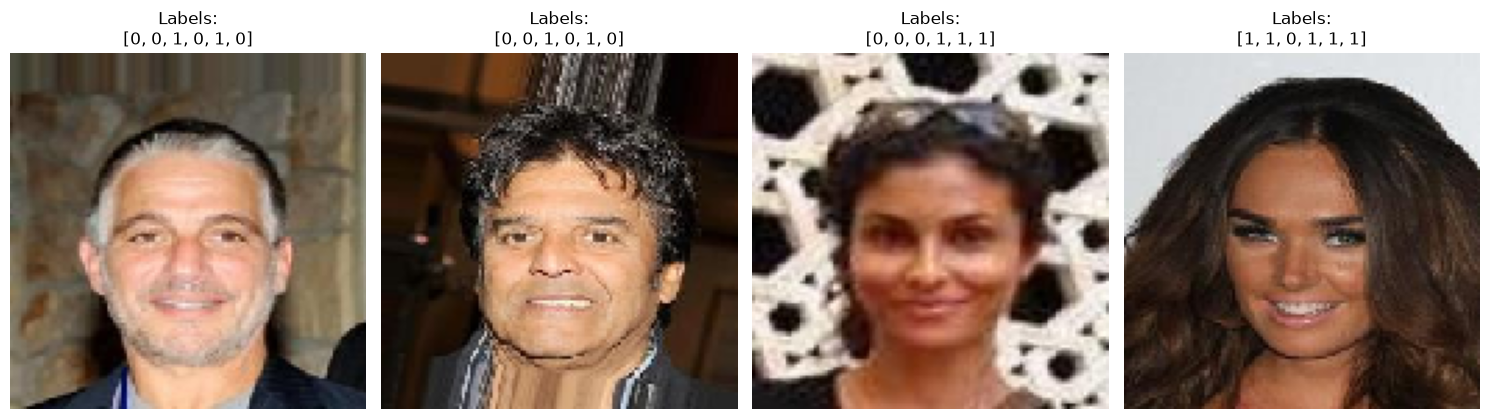

Building Approach 2: Transfer Learning Model...


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Starting Transfer Learning training...
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 88ms/step - accuracy: 0.2853 - loss: 0.4556 - val_accuracy: 0.2900 - val_loss: 0.4060
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 86ms/step - accuracy: 0.2871 - loss: 0.4266 - val_accuracy: 0.2889 - val_loss: 0.3962
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 86ms/step - accuracy: 0.2900 - loss: 0.4179 - val_accuracy: 0.2920 - val_loss: 0.3922
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.2914 - loss: 0.4151 - val_accuracy: 0.2866 - val_loss: 0.3944
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - accuracy: 0.2925 - loss: 0.4111 - val_accuracy: 0.2995 - val_loss: 0.3920


In [12]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# =========================================================
# 1. SPECIFICATIONS & DATA SETUP
# =========================================================
batch_size = 32
img_rows, img_cols = 128, 128
epochs = 5
target_size_tuple = (img_rows, img_cols)

csv_path = 'img_align_celeba_small/list_attr_celeba_small.csv'
image_dir_path = 'img_align_celeba_small/img_align_celeba_small/'

targets = ['Attractive', 'Heavy_Makeup', 'Male', 'Pointy_Nose', 'Smiling', 'Young']
num_classes = len(targets) # Ensures num_classes is explicitly defined

# Load and preprocess dataframe
df = pd.read_csv(csv_path)
df[targets] = df[targets].replace(-1, 0)

train_df = df[df['Eval'] == 0]
valid_df = df[df['Eval'] == 1]

# Print sample counts in your requested format
print(f"({len(train_df)}, {img_rows}, {img_cols}, 3) train samples")
print(f"({len(valid_df)}, {img_rows}, {img_cols}, 3) test samples")

# Setup data generators
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir_path,
    x_col='image_id',
    y_col=targets,
    target_size=target_size_tuple,
    batch_size=batch_size,
    class_mode='raw'
)

valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=image_dir_path,
    x_col='image_id',
    y_col=targets,
    target_size=target_size_tuple,
    batch_size=batch_size,
    class_mode='raw',
    shuffle=False
)

# =========================================================
# 2. VISUALIZE SAMPLES WITH BINARY LABELS
# =========================================================
sample_images, sample_labels = next(iter(train_generator))

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(sample_images[i])
    binary_array = sample_labels[i].astype(int).tolist()
    axes[i].set_title(f"Labels:\n{binary_array}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# 3. APPROACH 2: TRANSFER LEARNING (MobileNetV2)
# =========================================================
print("Building Approach 2: Transfer Learning Model...")

# Load pre-trained MobileNetV2 without its top classification layer
base_model = MobileNetV2(
    input_shape=(img_rows, img_cols, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model weights so pre-learned features are preserved
base_model.trainable = False

# Build custom classification head for our 6 attributes
inputs = Input(shape=(img_rows, img_cols, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Final output layer with sigmoid activation for multi-label classification
outputs = Dense(num_classes, activation='sigmoid')(x)

transfer_model = Model(inputs=inputs, outputs=outputs)
transfer_model.summary()

# =========================================================
# 4. COMPILE AND TRAIN TRANSFER LEARNING MODEL
# =========================================================
transfer_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['accuracy']
)

print("Starting Transfer Learning training...")
history_transfer = transfer_model.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    verbose=1
)